# Iteración 11: NB-SVM + negación + última cláusula en las vistas de palabras
**Curso:** Aprendizaje de Máquina 2026-20, Universidad de los Andes · **Parte 1** (ML clásico, solo scikit-learn)

Envío a Kaggle: `kaggle_iteraciones/iter11_nbsvm_negacion_clausulas.csv` · Modelo: `models/iteraciones/iter11_nbsvm_negacion_clausulas.joblib`

**Qué cambia respecto a la iteración anterior.** Se mantiene el stacking de la iteración 10, pero **cada vista de palabras cambia de representación**: negación marcada, bolsa binaria de unigramas y bigramas ponderada con **NB-SVM** y regresión logística. Se agrega una vista nueva con la **última cláusula**. Las dos vistas de n-gramas de caracteres siguen como en la 10.

**Por qué.** En la 10 casi todos los errores evitables estaban en reseñas polares sin frase de indecisión (acierto 0,935): opiniones negadas ("no es para nada lo que esperaba") y dos opiniones en una misma oración. El marcado de negación y la última cláusula atacan esos dos casos. La ponderación NB-SVM hace que cada vista se concentre en los términos que de verdad separan las clases y no en el relleno. Es un clásico para clasificar sentimiento con bolsa de palabras.

## 1. Configuración

In [1]:
import re
import unicodedata
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC

SEED = 42  # semilla fija: todo el notebook es replicable
np.random.seed(SEED)

# Funciona igual si el notebook se abre desde la raíz del proyecto o desde notebooks_iteraciones/
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = RAIZ / "data"
ENVIOS_DIR = RAIZ / "kaggle_iteraciones"        # archivos para subir a Kaggle
MODELOS_DIR = RAIZ / "models" / "iteraciones"   # modelo de cada iteración (joblib)
ENVIOS_DIR.mkdir(exist_ok=True)
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["negativo", "neutral", "positivo"]
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__)

scikit-learn 1.9.1 | pandas 3.0.6


## 2. Datos y corrección del texto
La misma corrección de `parte1convencional.ipynb` (sección 3.7): reparar la codificación dañada, quitar guiones invisibles, minúsculas y quitar tildes. Va **dentro** del modelo (como `preprocessor` o dentro de las funciones de cada vista), así que el modelo guardado recibe el texto original.

Partición igual que en `parte1convencional.ipynb`: 80 % entrenamiento / 20 % prueba, estratificada con `SEED = 42`. Las decisiones se toman con validación cruzada de 5 pliegues sobre el 80 %; la prueba solo se usa una vez, en la última iteración.

In [2]:
# Pares que deja una codificación dañada (UTF-8 leído como Latin-1) -> letra correcta
MOJIBAKE = {"Ã¡": "á", "Ã©": "é", "Ã\xad": "í", "Ã³": "ó", "Ãº": "ú", "Ã±": "ñ"}
# Variante en la que además la Ã perdió su tilde: "llegA3" -> "llegó"
MOJIBAKE_DEGRADADO = {"A¡": "á", "A©": "é", "A\xad": "í", "A3": "ó", "A³": "ó", "Aº": "ú", "A±": "ñ"}
PATRON_DEGRADADO = re.compile(r"(?<=[a-zñ])A[¡©\xad3³º±]")  # solo dentro de una palabra


def reparar_par(coincidencia):
    return MOJIBAKE_DEGRADADO[coincidencia.group()]


def corregir_texto(texto):
    """Devuelve una copia corregida del texto. No modifica el original."""
    for malo, bueno in MOJIBAKE.items():                 # 1. reparar la codificación dañada
        texto = texto.replace(malo, bueno)
    texto = PATRON_DEGRADADO.sub(reparar_par, texto)
    texto = texto.replace("\xad", "")                    # 2. quitar guiones invisibles
    texto = texto.lower()                                # 3. minúsculas
    texto = unicodedata.normalize("NFKD", texto)         # 4. quitar tildes y ñ
    return "".join(c for c in texto if not unicodedata.combining(c))


train = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")  # solo para predecir, nunca para entrenar
muestra = pd.read_csv(DATA_DIR / "sample_submission.csv")

X_ent, X_prueba, y_ent, y_prueba = train_test_split(
    train["text"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Entrenamiento: {len(X_ent)} | Prueba (sin tocar): {len(X_prueba)} | eval: {len(eval_df)}")

Entrenamiento: 9600 | Prueba (sin tocar): 2400 | eval: 3000


### Funciones para partir la reseña
El EDA mostró que el sentimiento global lo decide sobre todo **la opinión del final** (después de conectores como "aun así", "eso sí", "al final"). Estas funciones extraen partes del texto; después cada parte se representa con TF-IDF, como cualquier texto. Se definen con `def` en el notebook (no `lambda`) para que el modelo se pueda guardar y volver a cargar.

> ⚠️ Partir el texto antes de vectorizar sigue usando solo TF-IDF y clasificadores de scikit-learn, pero conviene **confirmarlo con la profesora o el monitor** antes de entregar un modelo de este tipo.

In [3]:
CONECTORES = ["aun asi", "eso si", "por otro lado", "por cierto", "de paso", "al final", "con todo",
              "a fin de cuentas", "sin embargo", "en fin", "despues de todo", "pero", "aunque", "ahora",
              "ademas", "no obstante", "de todas formas", "igual", "lo unico", "nada mas"]
PATRON_CONECTOR = re.compile(r"\b(" + "|".join(CONECTORES) + r")\b")
PATRON_ORACION = re.compile(r"(?<=[.;:!?])\s+")


def oraciones(texto):
    """Parte un texto ya corregido en oraciones."""
    return [o for o in PATRON_ORACION.split(texto.strip()) if o]


def texto_completo(textos):
    return [corregir_texto(t) for t in textos]


def ultima_oracion(textos):
    return [oraciones(corregir_texto(t))[-1] for t in textos]


def tras_ultimo_conector(textos):
    """Lo que va desde el último conector hasta el final (o la última oración si no hay conector)."""
    salida = []
    for t in textos:
        t = corregir_texto(t)
        conectores = list(PATRON_CONECTOR.finditer(t))
        salida.append(t[conectores[-1].start():] if conectores else oraciones(t)[-1])
    return salida


def vista(funcion, **parametros):
    """Una vista del texto: extraer una parte de la reseña y representarla con TF-IDF."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, **parametros))])


print(ultima_oracion(X_ent[:1])[0])
print(tras_ultimo_conector(X_ent[:1])[0])

por cierto, trae garantia de un ano.
por cierto, trae garantia de un ano.


### Más vistas y modelos base del stacking
- **Primera y penúltima oración:** en las reseñas mixtas, la opinión del inicio también cuenta.
- **Palabras marcadas con su conector:** "feliz" después de "aun así" se vuelve `aunasi_feliz`, distinta de `porotrolado_feliz`, para que el modelo aprenda qué conectores hacen ganar a lo que sigue.
- **Cierre indeciso:** si la reseña termina con "tengo sentimientos encontrados", "ni fu ni fa" o similares. En esas reseñas el final no es una opinión y la etiqueta es más difícil de predecir.

In [4]:
def primera_oracion(textos):
    return [oraciones(corregir_texto(t))[0] for t in textos]


def penultima_oracion(textos):
    salida = []
    for t in textos:
        partes = oraciones(corregir_texto(t))
        salida.append(partes[-2] if len(partes) > 1 else "")
    return salida


def con_conector(textos):
    """Cada palabra lleva pegado el conector que abre su oración: 'aunasi_feliz', 'porotrolado_harto', 'nada_llego'."""
    salida = []
    for t in textos:
        tokens = []
        for o in oraciones(corregir_texto(t)):
            conector = next((c for c in CONECTORES + ["la verdad"] if o.startswith(c)), "nada").replace(" ", "")
            tokens += [f"{conector}_{p}" for p in re.findall(r"\w\w+", o)]
        salida.append(" ".join(tokens))
    return salida


CIERRE = re.compile(r"sentimientos encontrados|con dudas|no me decido|cada quien|a criterio|ni lo mejor ni lo peor"
                    r"|ni tan bueno ni tan malo|hay de todo|sopes|para gustos|no se si me quedo|lo dejo a tu"
                    r"|cada cosa por su lado|nomas cuento|juzgue|no se que pensar|ahi lo dejo|mis dudas|ni fu ni fa"
                    r"|no sabria|en duda|que recomendar|de cada lado|otras no|no se bien")


def cierre_indeciso(textos):
    """Marca si la reseña cierra con una frase de indecisión ("tengo sentimientos encontrados", "ni fu ni fa")."""
    return ["cierre_si" if CIERRE.search(corregir_texto(t)) else "cierre_no" for t in textos]


def clasificador_de_vista(funcion, C=3):
    """Regresión logística entrenada con una sola vista del texto (modelo base del stacking)."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def tres_vistas(C=3):
    """El mejor modelo de una sola etapa (iteración 08): texto completo + tras el último conector + última oración."""
    return Pipeline([("vistas", FeatureUnion([("completo", vista(texto_completo)),
                                              ("tras_conector", vista(tras_ultimo_conector)),
                                              ("ultima", vista(ultima_oracion))])),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base():
    return [("tres_vistas", tres_vistas()),
            ("completo", clasificador_de_vista(texto_completo)),
            ("tras_conector", clasificador_de_vista(tras_ultimo_conector)),
            ("ultima", clasificador_de_vista(ultima_oracion)),
            ("primera", clasificador_de_vista(primera_oracion)),
            ("penultima", clasificador_de_vista(penultima_oracion)),
            ("con_conector", clasificador_de_vista(con_conector)),
            ("cierre", clasificador_de_vista(cierre_indeciso, C=1))]


print(con_conector(X_ent[:1])[0][:200])

nada_lo nada_compre nada_hace nada_un nada_par nada_de nada_meses nada_por nada_internet nada_llego nada_en nada_tres nada_dias nada_desde nada_que nada_llego nada_lo nada_uso nada_para nada_el nada_g


### Modelos base adicionales
- **Última oración de opinión:** se salta las oraciones finales de relleno o de indecisión. Las palabras de opinión se aprenden en `fit`, así que en la validación cruzada se aprenden solo con la parte de entrenamiento de cada pliegue (no hay fuga de información).
- **N-gramas de caracteres:** "mdia" o "cincco" no están en el vocabulario de palabras, pero comparten trozos de 2 a 5 letras con "media" y "cinco".
- **Antes del último conector:** la opinión que el conector contradice.

In [5]:
class UltimaOpinion(BaseEstimator, TransformerMixin):
    """Última oración que contiene alguna palabra de opinión y no es un cierre indeciso.

    Las palabras de opinión se aprenden en `fit` (las `k` de mayor peso en una regresión logística
    positivo contra negativo), así que en cada pliegue se aprenden solo con su parte de entrenamiento.
    """

    def __init__(self, k=400):
        self.k = k

    def fit(self, X, y):
        y = np.asarray(y)
        polares = y != "neutral"
        vectorizador = TfidfVectorizer(min_df=3)
        M = vectorizador.fit_transform(texto_completo(np.asarray(X)[polares]))
        pesos = LogisticRegression(C=1, max_iter=3000).fit(M, y[polares]).coef_[0]
        vocabulario = vectorizador.get_feature_names_out()
        self.palabras_opinion_ = set(vocabulario[np.argsort(-np.abs(pesos))[:self.k]])
        return self

    def transform(self, X):
        salida = []
        for t in X:
            partes = oraciones(corregir_texto(t))
            elegida = next((o for o in reversed(partes) if not CIERRE.search(o)
                            and set(re.findall(r"\w\w+", o)) & self.palabras_opinion_), partes[-1])
            salida.append(elegida)
        return salida


def antes_del_ultimo_conector(textos):
    salida = []
    for t in textos:
        t = corregir_texto(t)
        conectores = list(PATRON_CONECTOR.finditer(t))
        salida.append(t[:conectores[-1].start()] if conectores else "")
    return salida


def clasificador_de_caracteres(funcion, C=3):
    """N-gramas de caracteres (2 a 5) dentro de cada palabra: tolera errores de tipeo ("mdia", "cincco")."""
    return Pipeline([("parte", FunctionTransformer(funcion)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2, analyzer="char_wb", ngram_range=(2, 5))),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def modelos_base_ampliados():
    ultima_opinion = Pipeline([("parte", UltimaOpinion(k=400)),
                               ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                               ("clf", LogisticRegression(C=3, max_iter=3000))])
    return modelos_base() + [("ultima_opinion", ultima_opinion),
                             ("caracteres_tras_conector", clasificador_de_caracteres(tras_ultimo_conector)),
                             ("caracteres_ultima", clasificador_de_caracteres(ultima_oracion)),
                             ("antes_del_conector", clasificador_de_vista(antes_del_ultimo_conector))]


print(UltimaOpinion().fit(X_ent, y_ent).transform(X_ent[:3]))

['por cierto, trae garantia de un ano.', 'con todo, el material se ve defectuoso la verdad.', 'el epmaque no vale lo que cuesta.']


### Negación, cláusulas y ponderación NB-SVM
Tres cambios en **cómo se representa cada vista**:
- **Marcado de negación** (regla escrita a mano): las palabras que siguen a "no", "ni", "nunca", "sin"… hasta el siguiente signo de puntuación llevan el prefijo `no_`. Así "no lo recomiendo" produce `no_recomiendo`, distinto de `recomiendo`.
- **Última cláusula:** además de partir en oraciones, se corta antes de ", pero", " aunque", " y "…, porque a veces las dos opiniones van en la misma oración ("la pantalla es excelente, pero la batería no dura nada").
- **NB-SVM** (Wang y Manning, 2012): bolsa de unigramas y bigramas **binaria** en la que cada columna se multiplica por su *log-count ratio*, $r = \log\frac{p/\lVert p\rVert_1}{q/\lVert q\rVert_1}$, donde $p$ y $q$ cuentan en cuántas reseñas de la clase y del resto aparece el término (con suavizado $\alpha = 1$). Es una **ponderación de la bolsa de palabras**, como TF-IDF, pero que usa las etiquetas: los términos que separan bien las clases pesan más. Se calcula una vez por clase (una contra el resto) y los tres bloques se concatenan. Los $r$ se aprenden en `fit`, así que en la validación cruzada se calculan solo con la parte de entrenamiento de cada pliegue. El clasificador sigue siendo una regresión logística de scikit-learn.

In [6]:
# Marcado de negación y segmentación en cláusulas (reglas escritas a mano)
NEGADORES = {"no", "ni", "nunca", "sin", "tampoco", "jamas", "nada", "nadie", "ningun", "ninguna", "ninguno"}
PATRON_TOKEN = re.compile(r"\w+|[.,;:!?]")
PUNTUACION = set(".,;:!?")


def marcar_negacion_texto(texto):
    """'no lo recomiendo, la verdad' -> 'no no_lo no_recomiendo , la verdad' (el alcance termina en la puntuación)."""
    salida, negado = [], False
    for tok in PATRON_TOKEN.findall(texto):
        if tok in PUNTUACION:
            negado = False
            salida.append(tok)
        elif tok in NEGADORES:
            negado = True
            salida.append(tok)
        else:
            salida.append("no_" + tok if negado else tok)
    return " ".join(salida)


def marcar_negacion(textos):
    return [marcar_negacion_texto(t) for t in textos]


# Corte de cláusulas: fin de oración, o coma/espacio antes de un conector ("..., pero", " aunque ", " y ")
PATRON_CLAUSULA = re.compile(r"(?<=[.;:!?])\s+|,\s+(?=(?:pero|aunque|aun asi|sin embargo|eso si|y)\b)"
                             r"|\s+(?=(?:pero|aunque|y)\s)")


def clausulas_texto(texto_corregido):
    return [c.strip(" ,") for c in PATRON_CLAUSULA.split(texto_corregido.strip()) if c and c.strip(" ,")]


def ultima_clausula(textos):
    return [(clausulas_texto(corregir_texto(t)) or [""])[-1] for t in textos]


# NB-SVM (Wang y Manning, 2012): bolsa de n-gramas binaria escalada por el log-count ratio de cada clase
class EscaladoNBClase(BaseEstimator, TransformerMixin):
    """Escalado NB para UNA clase (la k-ésima en orden): r = log((p/|p|) / (q/|q|)), con p = alpha + conteos
    binarios (presencia) en la clase y q = alpha + conteos en el resto (una contra el resto).
    transform devuelve X * r. Los r se aprenden en fit, solo con los datos de entrenamiento del pliegue."""

    def __init__(self, k=0, alpha=1.0):
        self.k = k
        self.alpha = alpha

    def fit(self, X, y):
        y = np.asarray(y)
        Xb = X.tocsr().copy()
        Xb.data = np.ones_like(Xb.data)  # presencia / ausencia
        clase = np.unique(y)[self.k]
        p = self.alpha + np.asarray(Xb[y == clase].sum(0)).ravel()
        q = self.alpha + np.asarray(Xb[y != clase].sum(0)).ravel()
        self.r_ = np.log((p / p.sum()) / (q / q.sum()))
        return self

    def transform(self, X):
        return X.tocsr().multiply(self.r_).tocsr()


def escalado_nb(alpha=1.0):
    """NB-SVM multiclase: un bloque de features escaladas por cada clase (negativo, neutral, positivo),
    concatenados por FeatureUnion: [X * r_neg | X * r_neu | X * r_pos]."""
    return FeatureUnion([(f"clase_{k}", EscaladoNBClase(k=k, alpha=alpha)) for k in range(len(LABELS))])


def bolsa_nb_palabras():
    """Unigramas y bigramas binarios (norma L2) con negación marcada, escalados por NB."""
    return [("neg", FunctionTransformer(marcar_negacion)),
            ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(1, 2), binary=True, use_idf=False, norm="l2")),
            ("nb", escalado_nb(alpha=1.0))]


def vista_nb(funcion):
    return Pipeline([("parte", FunctionTransformer(funcion))] + bolsa_nb_palabras())


def clf_nb(funcion, C=1):
    """Modelo base: una vista del texto -> NB-SVM -> regresión logística."""
    return Pipeline([("vista", vista_nb(funcion)), ("clf", LogisticRegression(C=C, max_iter=3000))])


def clf_char_nb(funcion, C=1):
    """N-gramas de caracteres 2-5 dentro de palabra (toleran tipeos: "mdia", "cincco"), binarios + NB."""
    vista = Pipeline([("parte", FunctionTransformer(funcion)),
                      ("tfidf", TfidfVectorizer(min_df=2, ngram_range=(2, 5), binary=True, use_idf=False,
                                                norm="l2", analyzer="char_wb")),
                      ("nb", escalado_nb(alpha=1.0))])
    return Pipeline([("vista", vista), ("clf", LogisticRegression(C=C, max_iter=3000))])


def nb_tres(C=1):
    """Tres vistas NB-SVM (texto completo, tras el último conector, última oración) unidas -> LR."""
    vistas = [("completo", vista_nb(texto_completo)),
              ("tras_conector", vista_nb(tras_ultimo_conector)),
              ("ultima", vista_nb(ultima_oracion))]
    return Pipeline([("vistas", FeatureUnion(vistas)), ("clf", LogisticRegression(C=C, max_iter=3000))])


def ultima_opinion_nb(C=1):
    return Pipeline([("parte", UltimaOpinion(k=400)),
                     ("neg", FunctionTransformer(marcar_negacion)),
                     ("bow", TfidfVectorizer(min_df=2, ngram_range=(1, 2), binary=True, use_idf=False)),
                     ("nb", escalado_nb()),
                     ("clf", LogisticRegression(C=C, max_iter=3000))])


def cierre_lr():
    """Indicador de cierre indeciso -> LR (igual que en iter10)."""
    return Pipeline([("parte", FunctionTransformer(cierre_indeciso)),
                     ("tfidf", TfidfVectorizer(sublinear_tf=True, min_df=2)),
                     ("clf", LogisticRegression(C=1, max_iter=3000))])


def modelos_base_nb():
    """Los 13 modelos base del stack NB-SVM (en este orden)."""
    return [("nb_tres", nb_tres()),
            ("completo", clf_nb(texto_completo)),
            ("tras_conector", clf_nb(tras_ultimo_conector)),
            ("ultima", clf_nb(ultima_oracion)),
            ("primera", clf_nb(primera_oracion)),
            ("penultima", clf_nb(penultima_oracion)),
            ("con_conector", clf_nb(con_conector)),
            ("cierre", cierre_lr()),
            ("ultima_opinion", ultima_opinion_nb()),
            ("antes_del_conector", clf_nb(antes_del_ultimo_conector)),
            ("ultima_clausula", clf_nb(ultima_clausula)),
            ("caracteres_tras_conector", clf_char_nb(tras_ultimo_conector)),
            ("caracteres_ultima", clf_char_nb(ultima_oracion))]


print(marcar_negacion([corregir_texto("No lo recomiendo, la verdad. Funciona bien.")])[0])
print(ultima_clausula(["La pantalla es excelente, pero la bateria no dura nada."])[0])

no no_lo no_recomiendo , la verdad . funciona bien .
pero la bateria no dura nada.


## 3. Modelo

In [7]:
def modelos_base_iter11():
    """13 modelos base: vistas de palabras con NB-SVM + negación (más la última cláusula) y, como en la 10,
    las dos vistas de n-gramas de caracteres con TF-IDF + LR."""
    return modelos_base_nb()[:-2] + [("caracteres_tras_conector", clasificador_de_caracteres(tras_ultimo_conector)),
                                     ("caracteres_ultima", clasificador_de_caracteres(ultima_oracion))]


modelo = StackingClassifier(
    modelos_base_iter11(),
    # early_stopping=False: el modelo es el mismo al entrenar con 7.680, 9.600 o 12.000 reseñas
    # (con 'auto', scikit-learn activa la parada temprana a partir de 10.000 filas)
    final_estimator=HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, early_stopping=False,
                                                   random_state=SEED),
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
)
modelo

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('nb_tres', ...), ('completo', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",HistGradientB...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary <n_jobs>` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('completo', ...), ('tras_conector', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` 

## 4. Validación cruzada (5 pliegues sobre el 80 % de entrenamiento)

Accuracy en validación cruzada: 0.9076 ± 0.0065   (pliegues: [0.9161 0.8979 0.912  0.9094 0.9026])
F1 macro: 0.9120



              precision    recall  f1-score   support

    negativo      0.866     0.874     0.870      3369
     neutral      0.995     0.998     0.997      2861
    positivo      0.874     0.864     0.869      3370

    accuracy                          0.908      9600
   macro avg      0.912     0.912     0.912      9600
weighted avg      0.908     0.908     0.908      9600



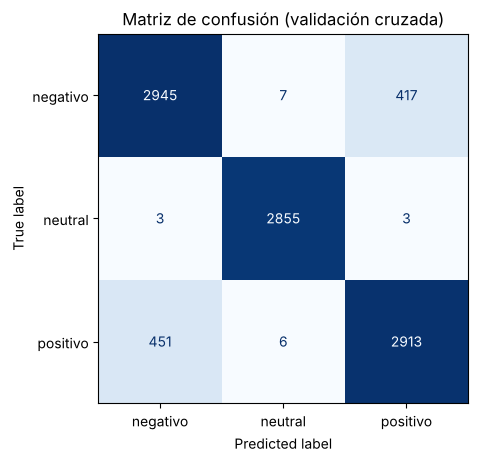

In [8]:
def validar(modelo):
    """Validación cruzada de 5 pliegues sobre entrenamiento: accuracy por pliegue y predicción fuera de pliegue de cada reseña."""
    res = cross_validate(modelo, X_ent, y_ent, cv=CV, n_jobs=-1, return_estimator=True, return_indices=True)
    pred = pd.Series(index=X_ent.index, dtype=object)
    for estimador, idx in zip(res["estimator"], res["indices"]["test"]):
        pred.iloc[idx] = estimador.predict(X_ent.iloc[idx])
    acc = res["test_score"]
    print(f"Accuracy en validación cruzada: {acc.mean():.4f} ± {acc.std():.4f}   (pliegues: {np.round(acc, 4)})")
    print(f"F1 macro: {f1_score(y_ent, pred, average='macro'):.4f}\n")
    print(classification_report(y_ent, pred, labels=LABELS, digits=3))
    ConfusionMatrixDisplay.from_predictions(y_ent, pred, labels=LABELS, cmap="Blues", colorbar=False)
    plt.title("Matriz de confusión (validación cruzada)"); plt.show()
    return acc.mean()


acc_cv = validar(modelo)

**Resultado.** Accuracy **0,9076 ± 0,0065** (F1 macro 0,912): **+0,6 puntos** sobre la iteración 10 (0,9012) con los mismos pliegues, y menos variación entre pliegues.
- `negativo` F1 0,870, `positivo` 0,869 (en la 10: 0,863 y 0,860) y `neutral` 0,997.
- La ganancia está en las reseñas polares **sin** frase de indecisión (acierto de 0,935 a 0,945) y en `neutral` (de 0,995 a 0,998): ahí estaban las negaciones y las dos opiniones en una misma oración. Las reseñas indecisas siguen cerca de 0,51, como se esperaba.
- En un análisis aparte con los mismos pliegues, frente a la iteración 10 corrige 388 reseñas y estropea 313 (prueba de McNemar, p = 0,005): la mejora no es ruido.

**Siguiente paso:** aplicar la misma representación a los n-gramas de caracteres.

## 5. Envío a Kaggle y modelo guardado
Se reentrena con **todo** `train.csv`, se predice `eval.csv`, se valida el formato (`id,answer`, 3.000 ids, etiquetas válidas) y se guardan el envío y el modelo. Al final se recarga el `.joblib` y se comprueba que reproduce el envío.

In [9]:
NOMBRE = "iter11_nbsvm_negacion_clausulas"

modelo_final = clone(modelo).fit(train["text"], train["label"])  # todo train.csv (12.000 reseñas)
envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})

assert list(envio.columns) == ["id", "answer"]
assert len(envio) == 3000 and envio["id"].is_unique and set(envio["id"]) == set(muestra["id"])
assert envio["answer"].isin(LABELS).all()

ruta_envio = ENVIOS_DIR / f"{NOMBRE}.csv"
ruta_modelo = MODELOS_DIR / f"{NOMBRE}.joblib"
envio.to_csv(ruta_envio, index=False)
joblib.dump(modelo_final, ruta_modelo, compress=3)

# Replicabilidad: el modelo guardado reproduce exactamente el envío
recargado = joblib.load(ruta_modelo)
assert (recargado.predict(eval_df["text"]) == pd.read_csv(ruta_envio)["answer"].values).all()
print(f"Envío: {ruta_envio.relative_to(RAIZ)} | modelo: {ruta_modelo.relative_to(RAIZ)} "
      f"({ruta_modelo.stat().st_size / 1e6:.1f} MB)")
print("Predicciones por clase:", envio["answer"].value_counts().to_dict())
print("El modelo recargado reproduce el envío: OK")

Envío: kaggle_iteraciones/iter11_nbsvm_negacion_clausulas.csv | modelo: models/iteraciones/iter11_nbsvm_negacion_clausulas.joblib (17.8 MB)
Predicciones por clase: {'negativo': 1092, 'positivo': 1084, 'neutral': 824}
El modelo recargado reproduce el envío: OK


## Historial de iteraciones
Accuracy en validación cruzada (5 pliegues sobre el 80 % de entrenamiento). Línea base trivial: 0,351.

| # | Iteración | Accuracy CV | Cambio (puntos) |
|---|---|---|---|
| 01 | Bolsa de palabras + Naive Bayes | 0,7047 | — |
| 02 | TF-IDF + regresión logística | 0,7252 | +2,0 |
| 03 | TF-IDF + Random Forest | 0,6760 | −4,9 |
| 04 | Regresión logística ajustada (GridSearchCV) | 0,7407 | +6,5 |
| 05 | Stacking clásico (logística + SVM + Naive Bayes) | 0,7420 | +0,1 |
| 06 | Solo la última oración | 0,8509 | +10,9 |
| 07 | Solo lo que va después del último conector | 0,8316 | −1,9 |
| 08 | Texto completo + tras el conector + última oración | 0,8869 | +5,5 |
| 09 | Stacking de vistas (metamodelo logístico) | 0,8942 | +0,7 |
| 10 | Stacking ampliado con metamodelo de boosting | 0,9012 | +0,7 |
| 11 | NB-SVM + negación + última cláusula en las vistas de palabras | 0,9076 | +0,6 |